In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")

import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="white", font='SimHei')

def get_db_connection():
    """建立 StarRocks 数据库连接 """
    return pymysql.connect(
        host='192.168.144.101',
        port=9030,
        user='hadoop',
        password='hadoop',
        charset='utf8'
    )

def fetch_data():
    """
    执行 SQL 查询：
    聚合全部分区的数据，计算每个城市的中位数总价的平均水平
    """
    conn = get_db_connection()
    # 路径：catalog.db.table
    # 使用 AVG 聚合全部分区的数据
    query = """
    SELECT 
        city, 
        AVG(median_total_price) as final_median_price
    FROM iceberg_catalog.ershoufang.ads_city_overview_daily
    GROUP BY city
    ORDER BY final_median_price DESC
    """
    try:
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

In [ ]:
def plot_median_price_lollipop():
    """优化后的棒棒糖图"""
    df = fetch_data()
    
    if df is None or df.empty:
        return

    # 动态调整画布大小，根据城市数量伸缩
    plt.figure(figsize=(16, 8))
    
    # 1. 绘制棒棒糖图
    # x: 城市名称, y: 聚合后的中位数价格
    markerline, stemlines, baseline = plt.stem(
        df['city'], 
        df['final_median_price'],
        linefmt='-',      
        markerfmt='o',    
        basefmt=" "       
    )

    # 2. 样式调优：统一颜色与透明度
    plt.setp(markerline, markerfacecolor='#4C72B0', markersize=9, markeredgecolor="white", alpha=1)
    plt.setp(stemlines, color='#4C72B0', linewidth=1, alpha=0.4)

    # 3. 标签避让
    # 为防止标签重叠, 对数值进行旋转，只在一定间隔或顶部显示
    y_max = df['final_median_price'].max()
    for i, val in enumerate(df['final_median_price']):
        plt.text(
            i, 
            val + (y_max * 0.02), 
            f'{val:.1f}', 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            rotation=45, 
            color='#333333'
        )

    # 4. 图表修饰
    plt.title('全部分区：各城市二手房中位数总价分布（综合平均值）', fontsize=16, pad=30)
    plt.ylabel('中位数总价 (万元)', fontsize=12)
    plt.xlabel('城市', fontsize=12)
    
    # 坐标轴标签优化
    plt.xticks(rotation=45, ha='right')
    
    # 辅助网格线
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    # 移除顶边和右边框
    sns.despine()
    
    plt.tight_layout()
    plt.show()

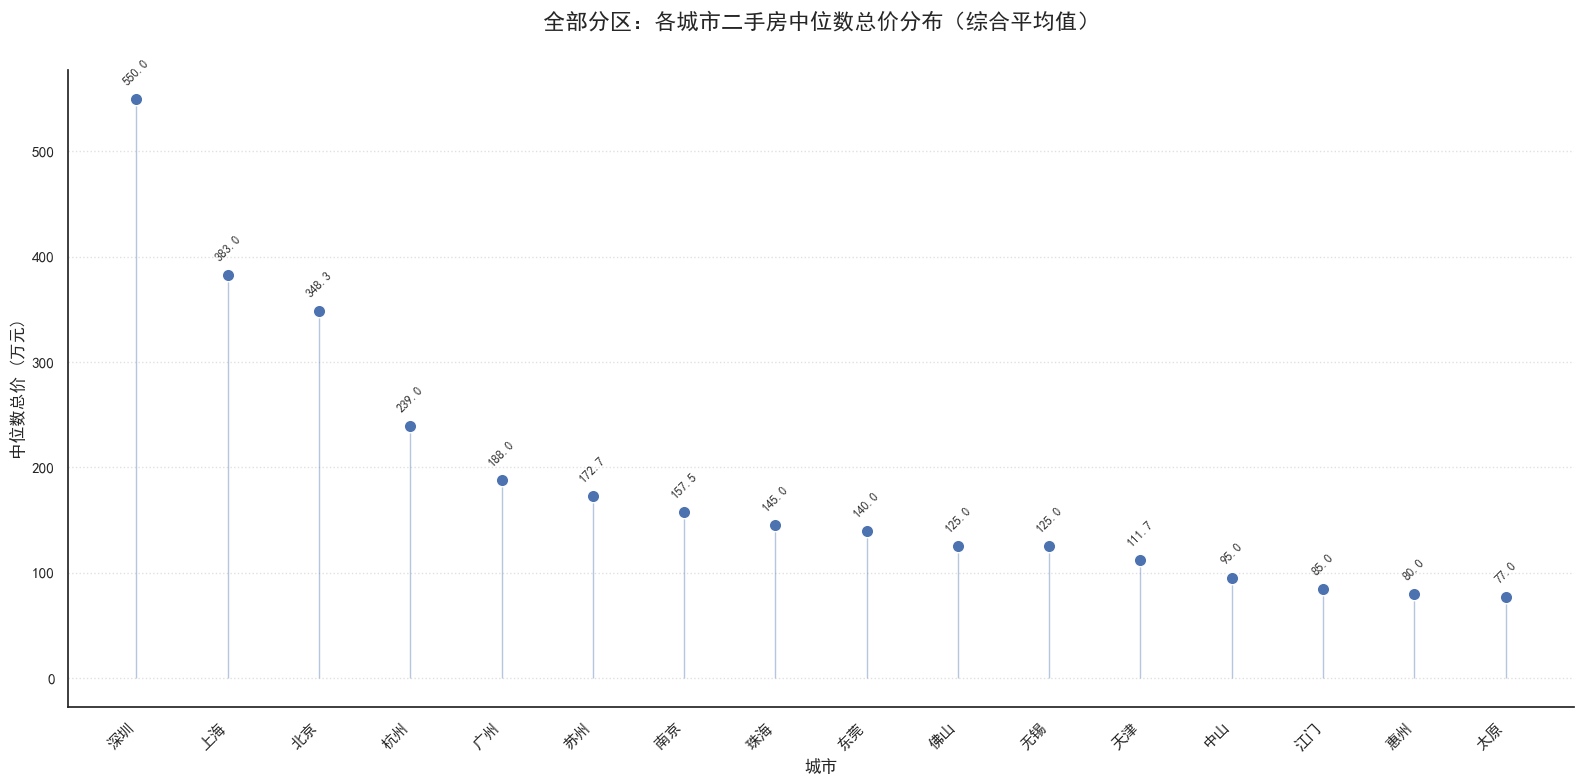

In [6]:
if __name__ == "__main__":
    plot_median_price_lollipop()